# graphs: after downloading and running sentiment analysis in finbert

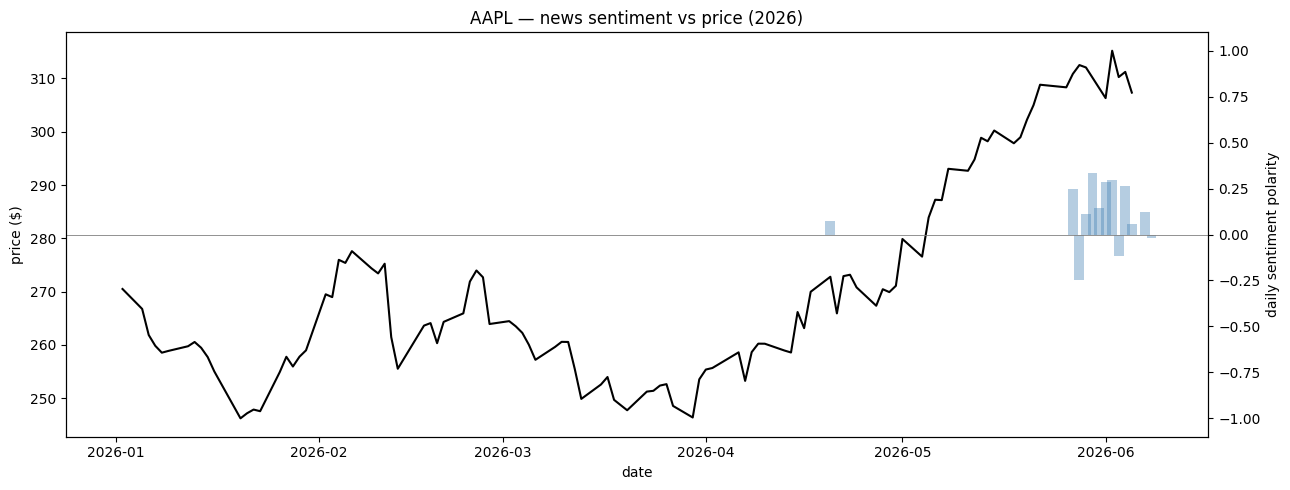

In [3]:
# 1- plot sentiment vs price for one ticker
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TICKER = "AAPL"

# 2- load daily sentiment for the ticker
daily = pd.read_csv("../raw_data/daily_sentiment.csv")
s = daily[daily["ticker"] == TICKER].copy()
s["date"] = pd.to_datetime(s["date"])
s = s.sort_values("date")

# 3- fetch price over the same window
start, end = s["date"].min(), s["date"].max()
px = yf.Ticker(TICKER).history(start=start, end=end)
px.index = px.index.tz_localize(None)  # drop timezone for clean plotting

# 4- plot both on twin axes
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(px.index, px["Close"], color="black", linewidth=1.5, label="price")
ax1.set_ylabel("price ($)")
ax1.set_xlabel("date")

ax2 = ax1.twinx()  # sentiment on the right axis
ax2.bar(s["date"], s["polarity"], width=1.5, alpha=0.4, color="steelblue", label="sentiment")
ax2.axhline(0, color="gray", linewidth=0.6)
ax2.set_ylabel("daily sentiment polarity")
ax2.set_ylim(-1.1, 1.1)

plt.title(f"{TICKER} — news sentiment vs price (2026)")
fig.tight_layout()
plt.savefig("../outputs/aapl_sentiment_vs_price.jpg", dpi=150, bbox_inches="tight")
plt.show()